In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import scipy.stats as stats
import matplotlib as mpl

In [2]:
def count_rk_windows(sequence):
  k=0
  for i in range(0,len(sequence) - 3):
    window = sequence[i:i+4]
    count=window.count('K')+window.count('R')-window.count('D')-window.count('E')
    if(count>1):
      k=k+1
  return k

In [3]:
def charge_density(sequence):
  count=sequence.count('K')+sequence.count('R')-sequence.count('D')-sequence.count('E')
  return count

In [4]:
df = pd.read_csv('uniprotkb_proteome_UP000002311_2025_04_17_final.tsv', sep='\t',on_bad_lines="skip").dropna()

In [5]:
df['PC']=df['Sequence'].apply(lambda x:(x.count('K')+x.count('R')))
df['NC']=df['Sequence'].apply(lambda x:(x.count('E')+x.count('D')))

In [6]:
df_mito_raw=df.loc[df['Subcellular location [CC]'].str.contains('Mitochondrion') & ~df['Subcellular location [CC]'].str.contains('Cytoplasm'),:]

In [7]:
df_mito_raw.shape

(1324, 11)

In [8]:
df_mito = df_mito_raw.drop_duplicates(subset='Entry').copy()

In [9]:
df_mito_synthase=df_mito.loc[df_mito['Protein names'].str.contains('ATP synthase'),:]

In [10]:
df_mito_complex3=df_mito.loc[df_mito['Protein names'].str.contains('b-c1'),:]

In [11]:
df_mito_complex4=df_mito.loc[df_mito['Protein names'].str.contains('c oxidase'),:]

In [12]:
df_mribo=df_mito.loc[df_mito['Protein names'].str.contains('ribosomal'),:]

In [13]:
df_ribo=df.loc[df['Protein names'].str.contains('ribosomal') & df['Subcellular location [CC]'].str.contains('Cytoplasm'),:]

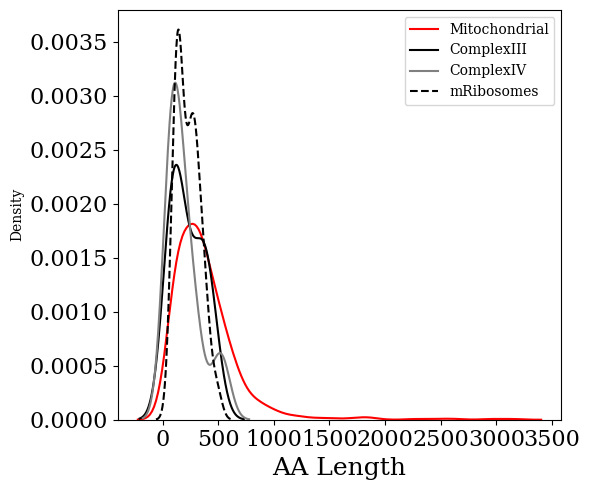

In [14]:
plt.rc('font',family='serif')
plt.figure(figsize=(6,5))
# sns.kdeplot(df['Length'],color='blue')
sns.kdeplot(df_mito['Length'],color='red')
sns.kdeplot(df_mito_complex3['Length'],color='black')
sns.kdeplot(df_mito_complex4['Length'],color='gray')
sns.kdeplot(df_mribo['Length'],color='black',linestyle='--')
# sns.kdeplot(df_ribo['Length'],color='green',linestyle='--')

plt.legend(['Mitochondrial','ComplexIII','ComplexIV','mRibosomes'])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('AA Length',fontsize=18)
plt.tight_layout()

In [15]:
df_mito['Net']=df_mito['Sequence'].apply(lambda x: count_rk_windows(x)/(len(x)))
df_mito['CD']=df_mito['Sequence'].apply(lambda x: charge_density(x)/(len(x)))

In [16]:
df_mito_synthase=df_mito.loc[df_mito['Protein names'].str.contains('ATP synthase'),:]

In [17]:
df_mito_complex3=df_mito.loc[df_mito['Protein names'].str.contains('b-c1'),:]

In [18]:
df_mito_complex4=df_mito.loc[df_mito['Protein names'].str.contains('c oxidase'),:]

In [19]:
df_mribo=df_mito.loc[df_mito['Protein names'].str.contains('ribosomal'),:]

In [20]:
for df in [df_mito_synthase, df_mito, df_mribo, df_mito_complex3, df_mito_complex4]:
    df['Gene_first'] = df['Gene Names'].str.split().str[0]

/tmp/ipykernel_343211/1084859661.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gene_first'] = df['Gene Names'].str.split().str[0]
/tmp/ipykernel_343211/1084859661.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gene_first'] = df['Gene Names'].str.split().str[0]
/tmp/ipykernel_343211/1084859661.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

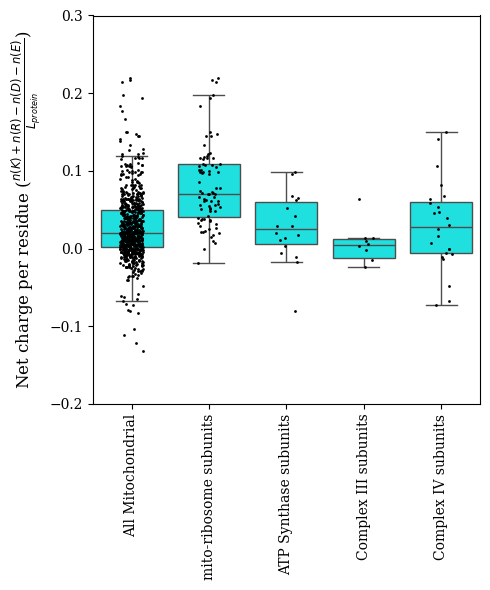

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plot_df = pd.concat([
    pd.DataFrame({'CD': df_mito['CD'],
                  'Type': 'All Mitochondrial',
                  'Gene': df_mito['Gene_first']}),
    pd.DataFrame({'CD': df_mribo['CD'],
                  'Type': 'mito-ribosome subunits',
                  'Gene': df_mribo['Gene_first']}),
    pd.DataFrame({'CD': df_mito_synthase['CD'],
                  'Type': 'ATP Synthase subunits',
                  'Gene': df_mito_synthase['Gene_first']}),
    pd.DataFrame({'CD': df_mito_complex3['CD'],
                  'Type': 'Complex III subunits',
                  'Gene': df_mito_complex3['Gene_first']}),
    pd.DataFrame({'CD': df_mito_complex4['CD'],
                  'Type': 'Complex IV subunits',
                  'Gene': df_mito_complex4['Gene_first']})
])

plt.figure(figsize=(5, 6))
ax = sns.stripplot(x='Type', y='CD', data=plot_df, s=2, jitter=0.15,color='k')
ax = sns.boxplot(x='Type', y='CD', data=plot_df,color='cyan',showfliers=False)

top5 = df_mito.sort_values('CD', ascending=False).head(5)
cats = list(plot_df['Type'].unique())
x_all_mito = cats.index('All Mitochondrial')
offsets = np.linspace(-0.25, 0.25, len(top5))

plt.ylim(-0.2,0.3)
plt.ylabel(r'Net charge per residue ($\frac{n(K)+n(R)-n(D)-n(E)}{L_{protein}}$)', fontsize=12)
plt.xlabel('', fontsize=12)
plt.xticks(fontsize=10, rotation=90)
plt.tight_layout()

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']  # exists on Mac, Illustrator knows it
plt.tight_layout()
plt.savefig("net_charge_per_residue_mitochondrial.svg", format="svg")